"""
DDPM written explicitly as a Markovian Hierarchical VAE (HVAE).

    Latents:   z_1 = x_1, z_2 = x_2, ..., z_T = x_T   (same dimension as data x_0)
    Encoder:   q(x_t | x_{t-1}) = N( sqrt(1-beta_t) x_{t-1}, beta_t I )     <- FIXED, no parameters
    Decoder:   p_theta(x_{t-1} | x_t) = N( mu_theta(x_t, t), sigma_t^2 I )  <- LEARNED
    Prior:     p(x_T) = N(0, I)

Training objective = negative ELBO (the VAE loss), split into
    L_T      = KL( q(x_T|x_0) || p(x_T) )                  prior matching   (no params)
    L_{t-1}  = KL( q(x_{t-1}|x_t,x_0) || p_theta(x_{t-1}|x_t) )  denoising matching, t=2..T
    L_0      = -log p_theta(x_0 | x_1)                     reconstruction

Runs on CPU in about a minute on a 2-D toy dataset (two moons).
"""

In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
# ----------------------------------------------------------------------------
# Data: 2-D "two moons"
# ----------------------------------------------------------------------------
def two_moons(n):
    n1 = n // 2
    n2 = n - n1
    a = torch.rand(n1) * math.pi
    b = torch.rand(n2) * math.pi
    upper = torch.stack([torch.cos(a), torch.sin(a)], 1)
    lower = torch.stack([1 - torch.cos(b), 0.5 - torch.sin(b)], 1)
    x = torch.cat([upper, lower]) + 0.05 * torch.randn(n, 2)
    return (x - x.mean(0)) / x.std(0)  # standardise

In [15]:
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
# ----------------------------------------------------------------------------
# Noise schedule: all the fixed "encoder" constants
# ----------------------------------------------------------------------------
class Schedule:
    def __init__(self, T=200, beta_1=1e-4, beta_T=0.02):
        self.T = T
        # index 0 is unused padding, so beta[t] matches the paper's beta_t for t = 1..T
        beta = torch.cat([torch.zeros(1), torch.linspace(beta_1, beta_T, T)])
        alpha = 1.0 - beta
        alpha_bar = torch.cumprod(alpha, 0)  # alpha_bar[0] = 1

        self.beta = beta.to(device)
        self.alpha = alpha.to(device)
        self.alpha_bar = alpha_bar.to(device)

        # Posterior q(x_{t-1} | x_t, x_0) = N(mu_tilde, beta_tilde I)
        ab_prev = torch.cat([torch.ones(1), alpha_bar[:-1]])
        self.alpha_bar_prev = ab_prev.to(device)
        self.beta_tilde = (beta * (1 - ab_prev) / (1 - alpha_bar).clamp(min=1e-12)).to(device)
        self.coef_x0 = (beta * ab_prev.sqrt() / (1 - alpha_bar).clamp(min=1e-12)).to(device)
        self.coef_xt = (alpha.sqrt() * (1 - ab_prev) / (1 - alpha_bar).clamp(min=1e-12)).to(device)

        # Decoder variance: sigma_t^2 = beta_t (Ho et al. choice)
        self.sigma2 = self.beta.clone()

In [5]:
def bcast(v, t):
    """Pick v[t] per sample and reshape for broadcasting against (B, D)."""
    return v[t].unsqueeze(-1)

In [6]:

# ----------------------------------------------------------------------------
# ENCODER  q  (fixed; this is what makes DDPM a *special* HVAE)
# ----------------------------------------------------------------------------
class FixedEncoder:
    def __init__(self, s: Schedule):
        self.s = s

    def step(self, x_prev, t):
        """One encoder layer: x_t ~ q(x_t | x_{t-1})."""
        b = bcast(self.s.beta, t)
        return (1 - b).sqrt() * x_prev + b.sqrt() * torch.randn_like(x_prev)

    def marginal(self, x0, t, eps=None):
        """Skip all layers at once: x_t ~ q(x_t | x_0) = N(sqrt(ab) x0, (1-ab) I)."""
        if eps is None:
            eps = torch.randn_like(x0)
        ab = bcast(self.s.alpha_bar, t)
        return ab.sqrt() * x0 + (1 - ab).sqrt() * eps, eps

    def posterior(self, x_t, x0, t):
        """q(x_{t-1} | x_t, x_0): the 'true' reverse step, tractable given x_0."""
        mean = bcast(self.s.coef_x0, t) * x0 + bcast(self.s.coef_xt, t) * x_t
        var = bcast(self.s.beta_tilde, t)
        return mean, var



In [7]:
# ----------------------------------------------------------------------------
# DECODER  p_theta  (learned; one network shared by all T layers, conditioned on t)
# ----------------------------------------------------------------------------
class EpsNet(nn.Module):
    """Predicts the noise eps from (x_t, t)."""

    def __init__(self, dim=2, hidden=128, T=200):
        super().__init__()
        self.t_embed = nn.Embedding(T + 1, hidden)
        self.inp = nn.Linear(dim, hidden)
        self.net = nn.Sequential(
            nn.SiLU(), nn.Linear(hidden, hidden),
            nn.SiLU(), nn.Linear(hidden, hidden),
            nn.SiLU(), nn.Linear(hidden, dim),
        )

    def forward(self, x, t):
        return self.net(self.inp(x) + self.t_embed(t))


class Decoder(nn.Module):
    def __init__(self, s: Schedule, dim=2):
        super().__init__()
        self.s = s
        self.eps_net = EpsNet(dim, T=s.T)

    def mean(self, x_t, t):
        """mu_theta(x_t, t) = 1/sqrt(alpha_t) * (x_t - beta_t / sqrt(1-alpha_bar_t) * eps_theta)."""
        eps_hat = self.eps_net(x_t, t)
        a = bcast(self.s.alpha, t)
        b = bcast(self.s.beta, t)
        ab = bcast(self.s.alpha_bar, t)
        return (x_t - b / (1 - ab).sqrt() * eps_hat) / a.sqrt(), eps_hat

    def var(self, t):
        return bcast(self.s.sigma2, t)

    @torch.no_grad()
    def sample(self, n, dim=2):
        """Ancestral sampling down the hierarchy: x_T ~ p(x_T), then x_{t-1} ~ p_theta(x_{t-1}|x_t)."""
        x = torch.randn(n, dim, device=device)
        for t in range(self.s.T, 0, -1):
            tt = torch.full((n,), t, device=device, dtype=torch.long)
            mu, _ = self.mean(x, tt)
            if t > 1:
                x = mu + self.var(tt).sqrt() * torch.randn_like(x)
            else:
                x = mu  # output the mean at the last layer
        return x

In [8]:
# ----------------------------------------------------------------------------
# Closed-form Gaussian terms
# ----------------------------------------------------------------------------
def kl_gauss(m1, v1, m2, v2):
    """KL( N(m1, v1 I) || N(m2, v2 I) ), summed over dims."""
    return 0.5 * (torch.log(v2 / v1) + (v1 + (m1 - m2) ** 2) / v2 - 1).sum(-1)


In [9]:
def gauss_nll(x, m, v):
    return 0.5 * (torch.log(2 * math.pi * v) + (x - m) ** 2 / v).sum(-1)

In [10]:

# ----------------------------------------------------------------------------
# The HVAE: ELBO and the simplified loss
# ----------------------------------------------------------------------------
class DDPM_HVAE(nn.Module):
    def __init__(self, T=200, dim=2):
        super().__init__()
        self.s = Schedule(T)
        self.enc = FixedEncoder(self.s)
        self.dec = Decoder(self.s, dim)

    def neg_elbo(self, x0):
        """
        Full variational bound, estimated without bias by sampling ONE layer t per example:
            -ELBO = L_T + sum_{t=2}^T L_{t-1} + L_0
                  = L_T + T * E_{t~U{1..T}} [ L_{t-1} ]   (L_0 at t = 1)
        """
        B = x0.shape[0]
        T = self.s.T
        t = torch.randint(1, T + 1, (B,), device=device)

        x_t, _ = self.enc.marginal(x0, t)
        mu_p, _ = self.dec.mean(x_t, t)
        var_p = self.dec.var(t)

        # t >= 2: KL between true posterior and decoder
        mu_q, var_q = self.enc.posterior(x_t, x0, t)
        kl = kl_gauss(mu_q, var_q.expand_as(mu_q), mu_p, var_p.expand_as(mu_p))
        # t == 1: reconstruction term
        rec = gauss_nll(x0, mu_p, var_p)
        layer_term = torch.where(t == 1, rec, kl)

        # L_T: prior matching (constant w.r.t. theta)
        ab_T = self.s.alpha_bar[T]
        L_T = kl_gauss(ab_T.sqrt() * x0, (1 - ab_T).expand_as(x0),
                       torch.zeros_like(x0), torch.ones_like(x0))

        return (L_T + T * layer_term).mean()

    def loss_simple(self, x0):
        """Ho et al. L_simple: E_{t, eps} || eps - eps_theta(x_t, t) ||^2 (reweighted ELBO)."""
        B = x0.shape[0]
        t = torch.randint(1, self.s.T + 1, (B,), device=device)
        x_t, eps = self.enc.marginal(x0, t)
        _, eps_hat = self.dec.mean(x_t, t)
        return F.mse_loss(eps_hat, eps)


step     1 | L_simple 1.0753 | -ELBO    6.008 nats
step  1000 | L_simple 0.5190 | -ELBO    1.405 nats
step  2000 | L_simple 0.5549 | -ELBO    2.306 nats
step  3000 | L_simple 0.4632 | -ELBO    1.772 nats
step  4000 | L_simple 0.4783 | -ELBO    0.707 nats
step  5000 | L_simple 0.4791 | -ELBO    0.985 nats
step  6000 | L_simple 0.4308 | -ELBO    1.052 nats

sample mean [ 0.01871368 -0.01017605]  data mean [-4.2724608e-08  3.0517577e-09]
sample std  [0.9969495 1.000027 ]  data std  [0.99999994 1.        ]
saved ddpm_hvae_samples.png


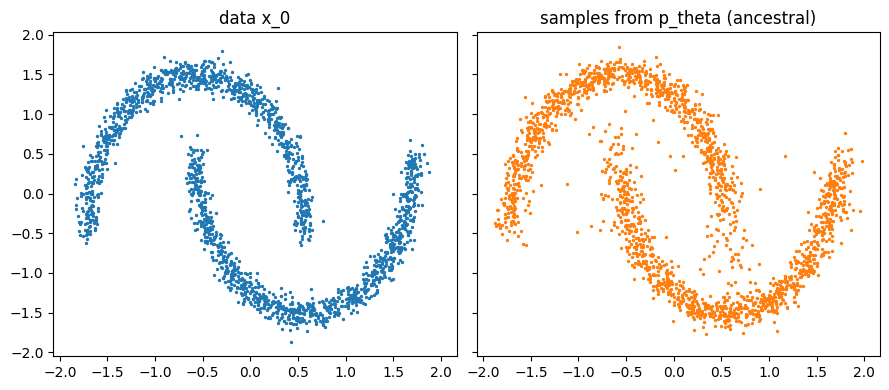

In [16]:

# ----------------------------------------------------------------------------
# Train & evaluate
# ----------------------------------------------------------------------------
def main(steps=6000, batch=512):
    data = two_moons(20000).to(device)
    model = DDPM_HVAE(T=200).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)

    for step in range(1, steps + 1):
        x0 = data[torch.randint(0, len(data), (batch,), device=device)]
        loss = model.loss_simple(x0)  # swap for model.neg_elbo(x0) to train on the exact ELBO
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
        if step % 1000 == 0 or step == 1:
            with torch.no_grad():
                nelbo = torch.stack([model.neg_elbo(data[torch.randint(0, len(data), (4096,), device=device)]) for _ in range(8)]).mean()
            print(f"step {step:5d} | L_simple {loss.item():.4f} | -ELBO {nelbo.item():8.3f} nats")

    samples = model.dec.sample(2000).cpu()
    print("\nsample mean", samples.mean(0).numpy(), " data mean", data.mean(0).cpu().numpy())
    print("sample std ", samples.std(0).numpy(), " data std ", data.std(0).cpu().numpy())

    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
        ax[0].scatter(*data[torch.randperm(len(data))[:2000]].cpu().T, s=2)
        ax[0].set_title("data x_0")
        ax[1].scatter(*samples.T, s=2, c="C1")
        ax[1].set_title("samples from p_theta (ancestral)")
        plt.tight_layout()
        plt.savefig("ddpm_hvae_samples.png", dpi=120)
        print("saved ddpm_hvae_samples.png")
    except ImportError:
        pass


if __name__ == "__main__":
    main()
